# 02 — Feature engineering

Builds one row per PPG from the weekly panel. Logic lives in `src/features.py`;
this just runs it and checks the output.

In [30]:
import sys
sys.path.insert(0, "../src")
import pandas as pd
from features import build_ppg_features, assign_ppg_id

raw = pd.read_csv("../data/raw/ECON_POS_anonymized.csv", low_memory=False)
feats = assign_ppg_id(build_ppg_features(raw))
feats.shape

(366, 38)

In [31]:
feats.isna().any().any(), feats.describe().T

(np.False_,
                            count          mean           std        min  \
 n_weeks                    366.0    115.887978     45.371236   3.000000   
 avg_weekly_sales           366.0  19898.930281  32362.146646  43.754449   
 avg_weekly_units           366.0   5200.930098   8201.898112  69.027523   
 avg_acv                    366.0     19.303512     22.944498   0.016218   
 sales_cv                   366.0      1.246805      0.985022   0.109784   
 is_new                     366.0      0.295082      0.456704   0.000000   
 is_delisted                366.0      0.147541      0.355130   0.000000   
 growth_rate                366.0     -0.024000      0.124000  -0.949969   
 acv_trend                  366.0     -0.111156      0.358999  -3.969848   
 momentum                   366.0      5.114113     75.368580   0.002254   
 mat_growth                 366.0    235.199971   4485.597283   0.000146   
 seasonality_index          366.0      1.963989      1.690162   0.108419   


## Distributions and correlation

Checking these before picking clustering features, not after.

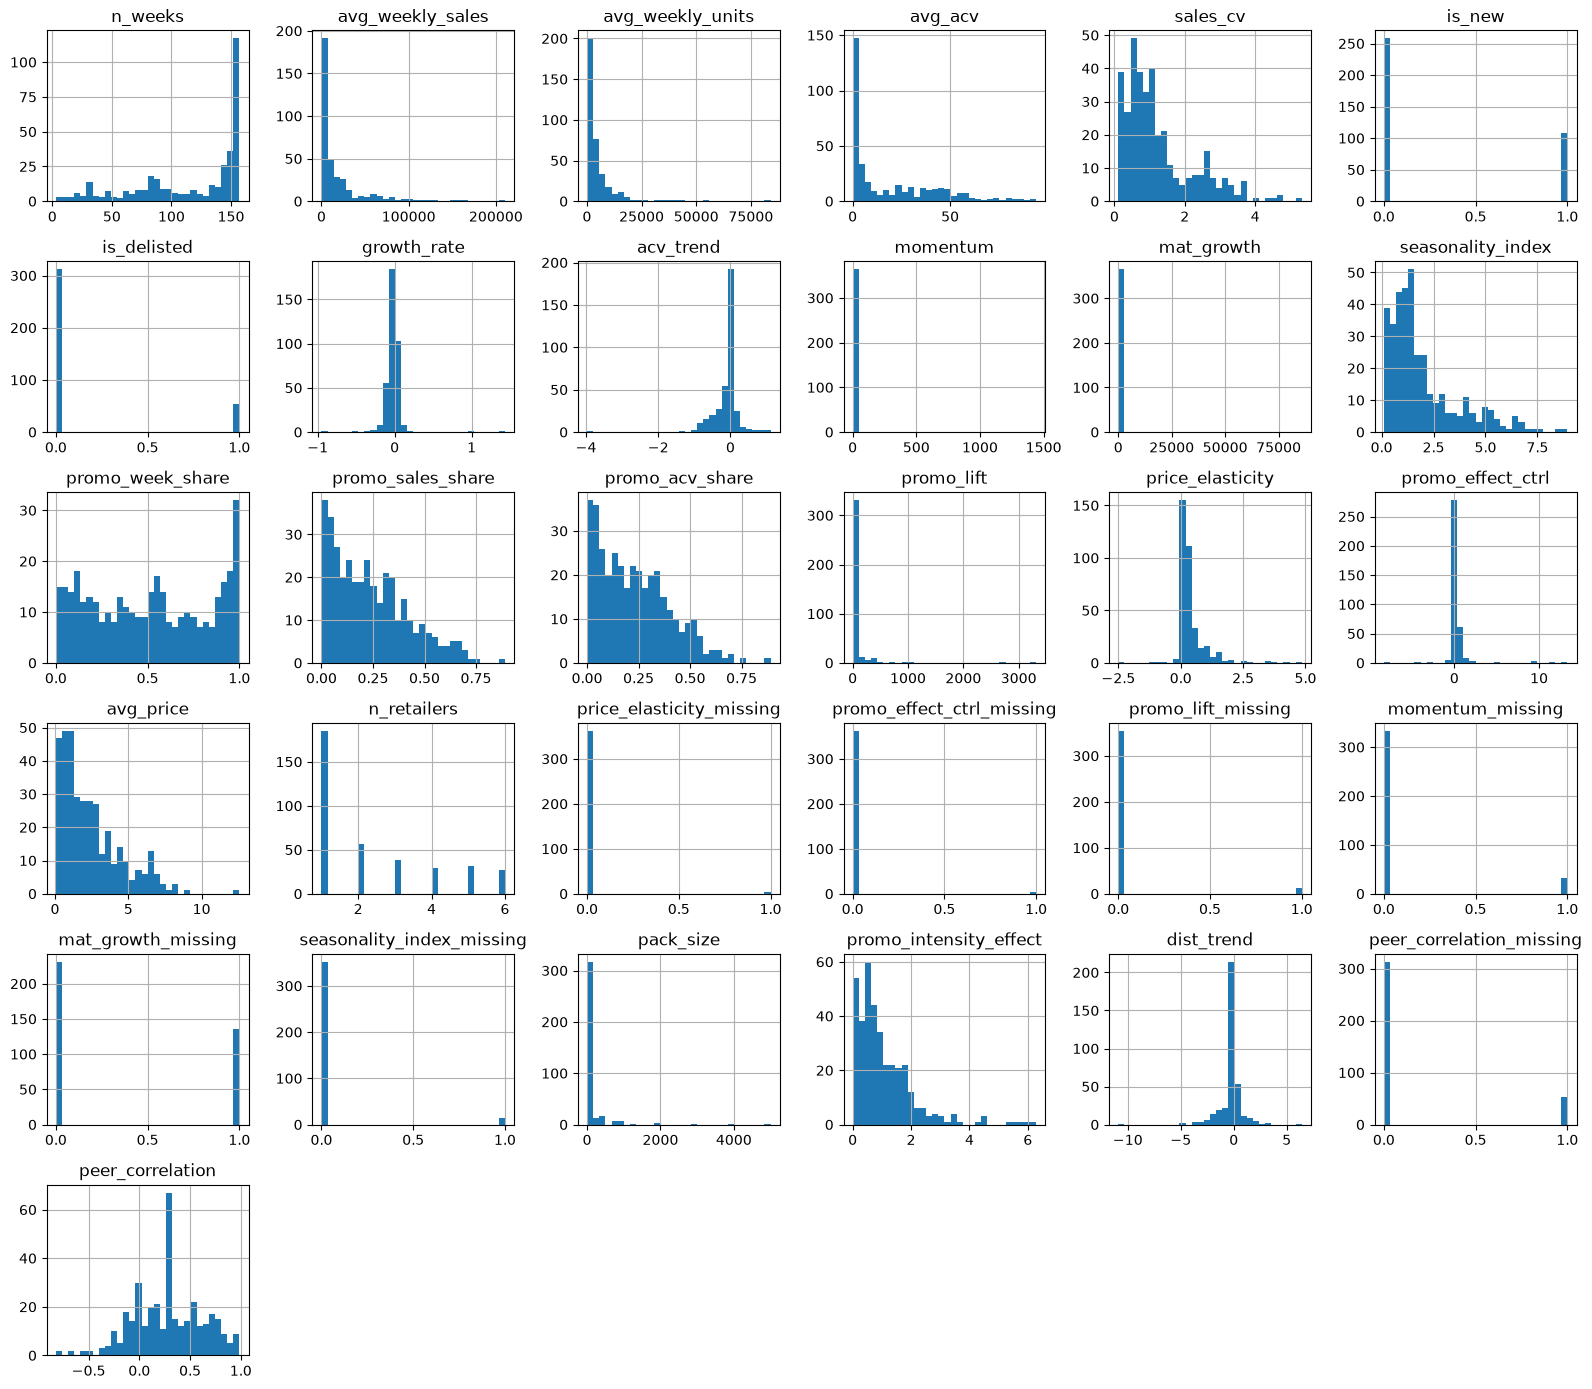

In [32]:
import matplotlib.pyplot as plt

FEATURE_COLS_CANDIDATE = [
    "n_weeks", "avg_weekly_sales", "avg_weekly_units", "avg_acv", "sales_cv",
    "is_new", "is_delisted", "growth_rate", "momentum", "mat_growth",
    "seasonality_index", "promo_week_share", "promo_sales_share",
    "promo_acv_share", "promo_lift", "price_elasticity", "promo_effect_ctrl",
    "avg_price", "n_retailers",
]
FEATURE_COLS_CANDIDATE = feats.select_dtypes(include="number").columns.tolist()
feats[FEATURE_COLS_CANDIDATE].hist(bins=30, figsize=(16, 14))
plt.tight_layout()
plt.show()

In [33]:
feats[FEATURE_COLS_CANDIDATE].skew().sort_values(ascending=False)

mat_growth                   19.131107
momentum                     19.062628
promo_lift                    9.501734
promo_effect_ctrl_missing     9.446792
price_elasticity_missing      9.446792
pack_size                     7.188506
promo_lift_missing            5.268894
promo_effect_ctrl             5.228122
seasonality_index_missing     4.834671
growth_rate                   4.727549
avg_weekly_units              4.666058
price_elasticity              2.883800
momentum_missing              2.873610
avg_weekly_sales              2.815967
promo_intensity_effect        2.167264
peer_correlation_missing      2.026977
is_delisted                   1.995865
seasonality_index             1.519187
sales_cv                      1.336606
avg_price                     1.235496
avg_acv                       1.152711
n_retailers                   1.012989
is_new                        0.902309
promo_sales_share             0.752294
promo_acv_share               0.725229
mat_growth_missing       

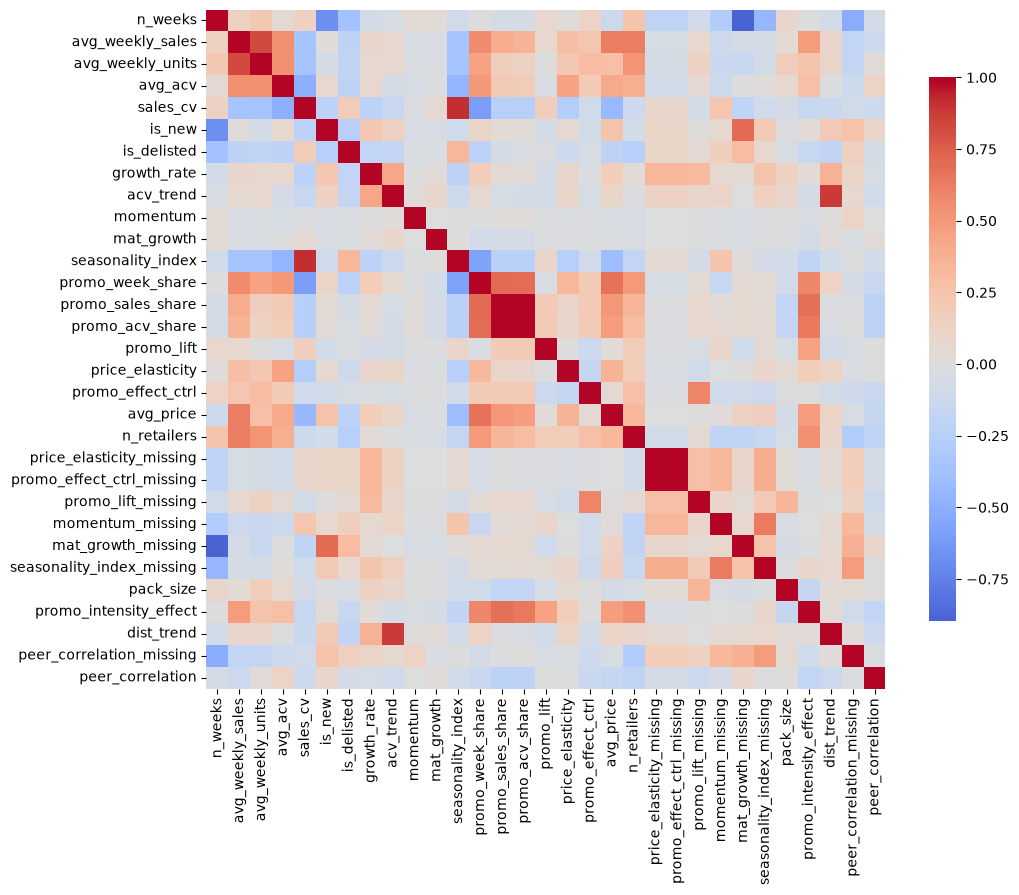

In [34]:
import seaborn as sns
import numpy as np

corr = feats[FEATURE_COLS_CANDIDATE].corr()
plt.figure(figsize=(11, 9))
sns.heatmap(corr, cmap="coolwarm", center=0, square=True, cbar_kws={"shrink": 0.8})
plt.tight_layout()
plt.show()

In [35]:
pairs = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool)).stack()
pairs.reindex(pairs.abs().sort_values(ascending=False).index).head(6)

price_elasticity_missing  promo_effect_ctrl_missing    1.000000
promo_sales_share         promo_acv_share              0.989523
sales_cv                  seasonality_index            0.916975
n_weeks                   mat_growth_missing          -0.894967
acv_trend                 dist_trend                   0.879222
avg_weekly_sales          avg_weekly_units             0.822930
dtype: float64

`promo_sales_share`/`promo_acv_share` (0.99) and `sales_cv`/`seasonality_index`
(0.92) are near-duplicates — keep one of each in `clustering.py`'s
`FEATURE_COLS`, not both. `momentum`, `mat_growth`, `promo_lift` and a few
others are heavily skewed (see above) — log-transform before scaling.

In [36]:
import os
os.makedirs("../data/processed", exist_ok=True)
feats.to_csv("../data/processed/ppg_features.csv")

## Interaction features

Three features live directly in `features.py` now, not a separate module:

- `promo_intensity_effect = promo_week_share * log1p(promo_lift)` - promo
  frequency x effectiveness. Built on log-scale, not raw: raw `promo_lift`
  came out 0.95 correlated with itself alone (its outlier variance swamps
  the bounded 0-1 factor) -- log1p balances both parents (0.59/0.46 split).
- `dist_trend = avg_acv * signed_log(growth_rate)` - distribution x trend.
- `peer_correlation` - a PPG's average significant correlation with
  same-brand peers (residual sales, market-factor removed, Bonferroni-
  corrected). The heaviest of the three, but it's the same correlation
  machinery computed once, right here -- no separate interactions module
  needed just to get this one feature.

All three are already in `feats` above (see the describe() output at the
top) and saved in `ppg_features.csv`.

## Notes

- Grain is `rgm_ppg`; `product_id` is unreliable (precision loss upstream).
- Gap-filling matters — ~32% of ppg-retailer series have real coverage gaps.
- `discount_depth` was attempted and dropped: `any_promo_units`/`amt` don't
  behave like real transacted promo volume.
- `momentum` (12wk) and `mat_growth` (52wk, season-controlled) are both kept
  — different signals, near-zero correlation.
- `ppg_id` added for readable downstream use; `rgm_ppg` kept as a column.
- `price_tier`, `form`, `benefit_type` added as metadata (not clustering
  inputs) — `price_tier` is a real, business-labelled tier, not decorative:
  avg price scales from $1.50 (CLASSIC) to $3.29 (PREMIUM). Needed for the
  brief's "price tiers... insufficiently covered" white-space question,
  which nothing else in this feature set can answer.